# 00 · Data audit: what's actually in StatsBomb 360?

Before modelling anything we need honest answers to:
1. How much data is there, per competition and per split?
2. How much of the pitch does a freeze frame actually show, and how many players?
3. For corners: can we infer the first-touch player reliably (limitation A)?
   How many labels survive, how noisy are they, and how sensitive is that to thresholds?

Data: StatsBomb Open Data (see ATTRIBUTION.md).

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display
from phds.data.freeze_frames import load_table
from phds.data.labels import build_corner_dataset
from phds.viz.pitch import plot_freeze_frame

pd.set_option("display.width", 140)
OUT = Path("../reports/m0"); OUT.mkdir(parents=True, exist_ok=True)
matches, events, frames, corners = (load_table(n) for n in ["matches", "events", "frames", "corners"])
players = load_table("players")  # ~25M rows, ~600 MB in memory
matches["comp"] = matches["competition_competition_name"] + " " + matches["season_season_name"]
comp_of = matches.set_index("match_id")["comp"]

def frame_players(event_id):
    return players[players["event_id"] == event_id]

def frame_area(event_id):
    return frames.loc[frames["event_id"] == event_id, "visible_area"].iloc[0]

## 1. Coverage

In [2]:
ev = events.assign(comp=events["match_id"].map(comp_of))
ev["has_frame"] = ev["event_id"].isin(frames["event_id"])
cov = ev.groupby("comp").agg(matches=("match_id", "nunique"), events=("event_id", "size"),
                             frames=("has_frame", "sum"))
cov["frame_rate"] = (cov["frames"] / cov["events"]).round(3)
cov.loc["TOTAL"] = [cov["matches"].sum(), cov["events"].sum(), cov["frames"].sum(),
                    round(cov["frames"].sum() / cov["events"].sum(), 3)]
cov

,matches,events,frames,frame_rate
comp,,,,
1. Bundesliga 2023/2024,34.0,137765.0,108394.0,0.787
African Cup of Nations 2023,1.0,3374.0,1.0,0.000
FIFA World Cup 2022,64.0,234637.0,203882.0,0.869
La Liga 2020/2021,35.0,139030.0,128840.0,0.927
Ligue 1 2021/2022,26.0,101766.0,86352.0,0.849
Ligue 1 2022/2023,32.0,129490.0,108222.0,0.836
Major League Soccer 2023,6.0,21786.0,9600.0,0.441
UEFA Euro 2020,51.0,192664.0,166871.0,0.866
UEFA Euro 2024,51.0,187924.0,164530.0,0.876


In [3]:
# Which event types get freeze frames?
ev.groupby("type")["has_frame"].agg(["size", "mean"]).sort_values("size", ascending=False).head(15).round(3)

,size,mean
type,,
Pass,447978,0.834
Ball Receipt*,423782,0.876
Carry,360885,0.895
Pressure,135797,0.873
Ball Recovery,41495,0.879
Duel,27488,0.862
Block,16758,0.881
Clearance,16542,0.911
Goal Keeper,13359,0.452


## 2. What does a frame show?
StatsBomb 360 comes from broadcast video, so a frame only shows what the camera saw.
`visible_frac` is the share of the 120×80 pitch covered by the visible-area polygon.

,n_players,n_teammates,n_opponents,visible_frac
kind,,,,
corner,19.0,8.0,11.0,0.16
other event,16.0,8.0,8.0,0.27
other pass,16.0,8.0,9.0,0.29


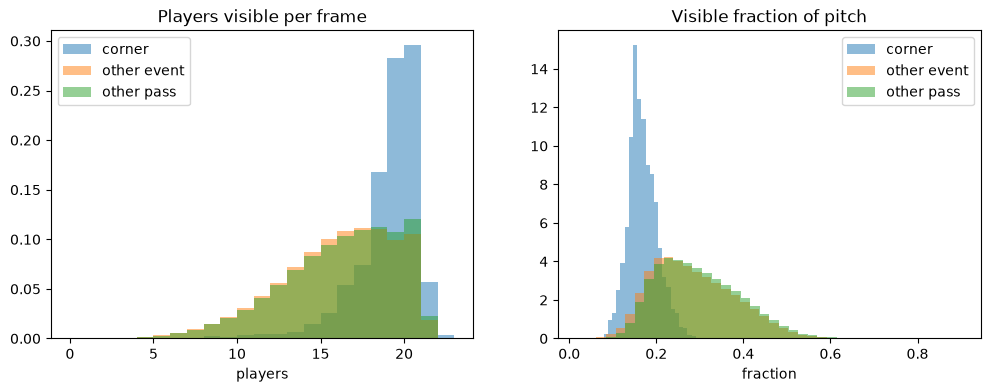

In [4]:
f = frames.merge(events[["event_id", "type", "pass_type"]], on="event_id", how="left")
f["kind"] = np.where(f["pass_type"].eq("Corner"), "corner",
             np.where(f["type"].eq("Pass"), "other pass", "other event"))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for kind, g in f.groupby("kind"):
    axes[0].hist(g["n_players"], bins=np.arange(0, 24), alpha=.5, density=True, label=kind)
    axes[1].hist(g["visible_frac"].dropna(), bins=40, alpha=.5, density=True, label=kind)
axes[0].set(title="Players visible per frame", xlabel="players"); axes[0].legend()
axes[1].set(title="Visible fraction of pitch", xlabel="fraction"); axes[1].legend()
fig.savefig(OUT / "visibility.png", dpi=150, bbox_inches="tight")
f.groupby("kind")[["n_players", "n_teammates", "n_opponents", "visible_frac"]].median().round(2)

## 3. Passes: labels available for the completion model (M2)
StatsBomb records the *intended* recipient even for incomplete passes. That's useful:
failed passes still say who the passer was aiming for.

In [5]:
p = events[(events["type"] == "Pass") & events["event_id"].isin(frames["event_id"])]
open_play = p[p["pass_type"].isna()]  # no set-piece type = open play
incomplete = open_play[open_play["pass_outcome"].ne("Complete")]
pd.Series({
    "passes with frame": len(p),
    "open play": len(open_play),
    "completion rate (open play)": round(open_play["pass_outcome"].eq("Complete").mean(), 3),
    "incomplete passes": len(incomplete),
    "...with intended recipient": round(incomplete["pass_recipient_id"].notna().mean(), 3),
    "incomplete outcome mix": incomplete["pass_outcome"].value_counts(normalize=True).round(2).to_dict(),
}).to_frame("value")

,value
passes with frame,373640
open play,322036
completion rate (open play),0.841
incomplete passes,51091
...with intended recipient,0.739
incomplete outcome mix,"{'Incomplete': 0.86, 'Out': 0.1, 'Pass Offside..."


## 4. Corners: first-touch label audit (limitation A)
Label pipeline (see `phds/data/labels.py`):
1. first on-ball event within 6 s of the corner;
2. link the toucher to a dot in the corner frame, by two methods:
   **nearest** (closest player to the touch location) and
   **assign** (Hungarian matching of the whole team between the corner frame and the touch
   event's own frame, where the toucher is flagged `actor`);
3. keep a confident assignment, else a confident nearest match not contradicted by assignment.
   If both are confident and disagree, drop it ("conflict").

In [6]:
print(len(corners), "corners;", corners["n_players"].notna().sum(), "with a freeze frame",
      f"({corners['n_players'].notna().mean():.0%}, vs {ev['has_frame'].mean():.0%} of all events)")
display(corners["label_status"].value_counts().to_frame("count"))
display(pd.crosstab([corners["label_team"], corners["label_method"]], corners["label_status"], margins=True))
ok = corners[corners["label_status"] == "ok"]
print("usable labels per split:"); display(pd.crosstab(ok["split"], ok["label_team"], margins=True))
print(f"into box: {corners['into_box'].mean():.1%}   shot within 20s: {corners['shot_within'].mean():.1%}")

4020 corners; 2468 with a freeze frame (61%, vs 86% of all events)


,count
label_status,
no_frame,1552
ok,1364
ambiguous,832
too_far,132
no_touch,117
conflict,22
no_candidates,1


label_status             ambiguous  conflict  no_candidates    ok  too_far   All
label_team label_method                                                         
attack     assign              280         0              1   509       97   887
           both                  0        10              0     0        0    10
           keeper                0         0              0     1        0     1
           nearest               1         0              0   124        8   133
defence    assign              539         0              0   350       22   911
           both                  0        12              0     0        0    12
           keeper                0         0              0   290        0   290
           nearest              12         0              0    90        5   107
All                            832        22              1  1364      132  2351

usable labels per split:


label_team,attack,defence,All
split,,,
test,86,79,165
train,463,544,1007
val,85,107,192
All,634,730,1364


into box: 78.0%   shot within 20s: 37.2%


### Label-noise estimate
Where *both* methods are independently confident, how often do they pick the same player?
They use different evidence (touch location vs whole-team movement), so their agreement
is a practical proxy for label accuracy. It's an upper bound on accuracy: two methods can
agree and both be wrong, e.g. when two players cross paths.

In [7]:
both = corners[(corners["nearest_status"] == "ok") & (corners["assign_status"] == "ok")]
agree = both["nearest_idx"] == both["assign_idx"]
print(f"both confident: {len(both)}   agreement: {agree.mean():.1%}")
both.assign(agree=agree).groupby("label_team")["agree"].agg(["size", "mean"]).round(3)

both confident: 460   agreement: 94.3%


,size,mean
label_team,,
attack,270,0.963
defence,190,0.916


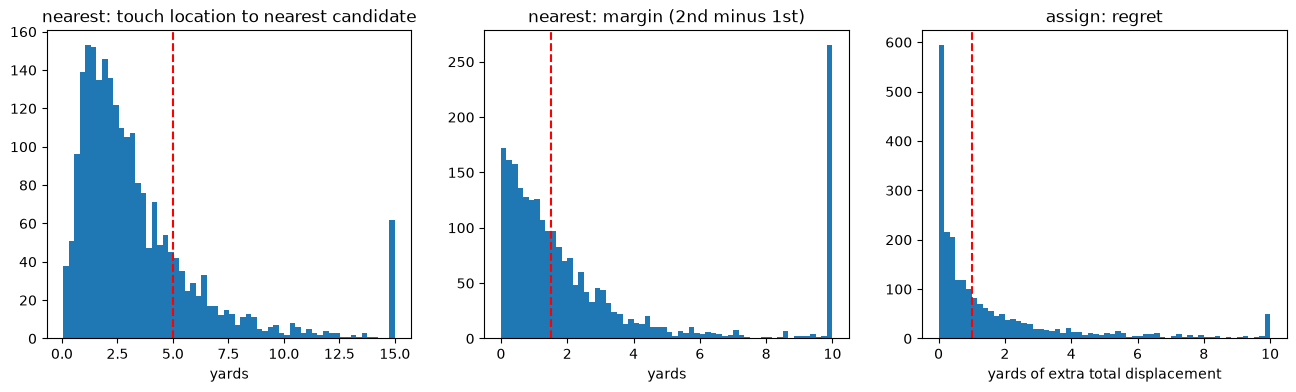

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
lab = corners.dropna(subset=["nearest_d"])
axes[0].hist(lab["nearest_d"].clip(upper=15), bins=60); axes[0].axvline(5, c="r", ls="--")
axes[0].set(title="nearest: touch location to nearest candidate", xlabel="yards")
axes[1].hist(lab["nearest_margin"].clip(upper=10), bins=60); axes[1].axvline(1.5, c="r", ls="--")
axes[1].set(title="nearest: margin (2nd minus 1st)", xlabel="yards")
axes[2].hist(corners["assign_regret"].dropna().clip(upper=10), bins=60); axes[2].axvline(1.0, c="r", ls="--")
axes[2].set(title="assign: regret", xlabel="yards of extra total displacement")
fig.savefig(OUT / "corner_label_distances.png", dpi=150, bbox_inches="tight")

### Sensitivity: how many labels survive under different thresholds?
Sample size vs label noise, on a 120-match subsample for speed. In M1 we re-check that
model rankings don't change under a stricter setting.

In [9]:
sub_ids = pd.Series(corners["match_id"].unique()).sample(120, random_state=0)
sub_events = events[events["match_id"].isin(sub_ids)]
grid = []
for min_regret in [0.5, 1.0, 2.0]:
    for margin in [0.5, 1.5, 3.0]:
        c = build_corner_dataset(sub_events, players, frames, margin=margin, min_regret=min_regret)
        labelled = c["label_team"].notna()
        grid.append(dict(min_regret=min_regret, margin=margin,
                         ok_frac=round((c.loc[labelled, "label_status"] == "ok").mean(), 3),
                         conflict_frac=round((c.loc[labelled, "label_status"] == "conflict").mean(), 3)))
grid = pd.DataFrame(grid)
print("share of touched corners with a usable label"); display(grid.pivot(index="min_regret", columns="margin", values="ok_frac"))
print("share dropped as conflicts"); display(grid.pivot(index="min_regret", columns="margin", values="conflict_frac"))

share of touched corners with a usable label


margin,0.5,1.5,3.0
min_regret,,,
0.5,0.652,0.661,0.655
1.0,0.608,0.581,0.550
2.0,0.560,0.495,0.440


share dropped as conflicts


margin,0.5,1.5,3.0
min_regret,,,
0.5,0.069,0.026,0.005
1.0,0.039,0.010,0.003
2.0,0.010,0.003,0.002


### Hand check
Random `ok` corners: gold ring = taker, dashed ring = inferred first-touch player,
black × = recorded touch location, grey = camera's visible area.

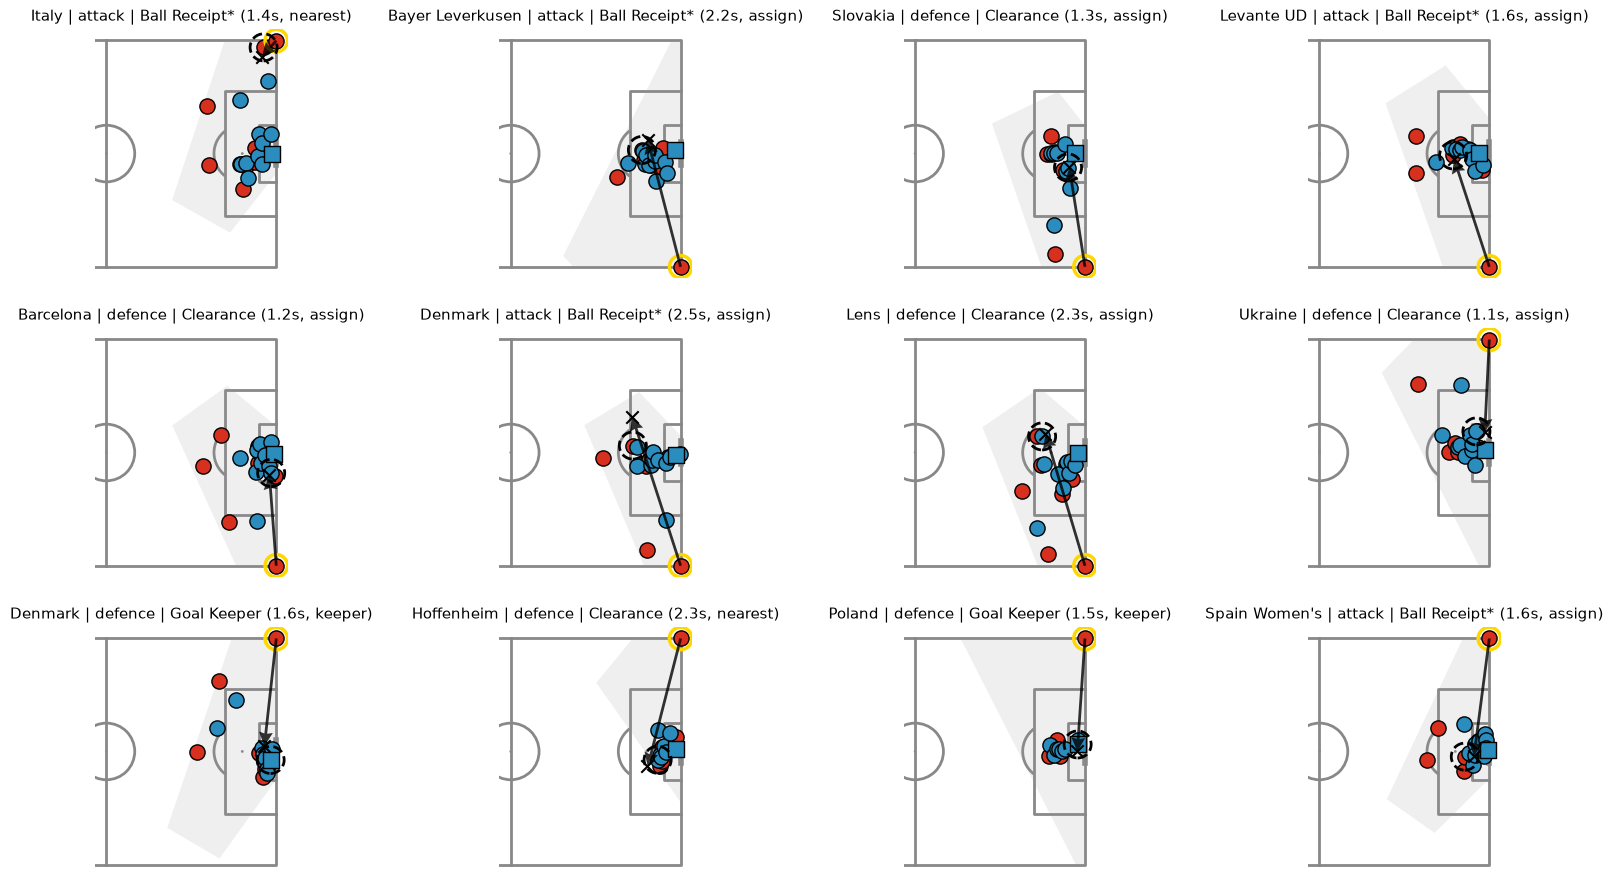

In [10]:
sample = ok.sample(12, random_state=0)
fig, axes = plt.subplots(3, 4, figsize=(20, 11))
for ax, (_, c) in zip(axes.flat, sample.iterrows()):
    plot_freeze_frame(frame_players(c["event_id"]), frame_area(c["event_id"]),
        highlight_idx=int(c["receiver_idx"]), half=True, ax=ax,
        passes=[dict(start=(c["x"], c["y"]), end=(c["end_x"], c["end_y"]), color="k")],
        title=f"{c['team']} | {c['label_team']} | {c['touch_type']} ({c['touch_dt']:.1f}s, {c['label_method']})")
    ax.scatter(c["touch_x"], c["touch_y"], marker="x", c="k", s=80, zorder=7)
fig.savefig(OUT / "corner_label_handcheck.png", dpi=120, bbox_inches="tight")

## 5. Famous moments
Goal-assisting passes in tournament finals that have a freeze frame.

,minute,team,player,pass_recipient,comp
241665,35,Argentina,Alexis Mac Allister,Ángel Fabián Di María Hernández,FIFA World Cup 2022
243474,80,France,Marcus Thuram,Kylian Mbappé Lottin,FIFA World Cup 2022
850119,46,Spain,Lamine Yamal Nasraoui Ebana,Nicholas Williams Arthuer,UEFA Euro 2024
851056,72,England,Jude Bellingham,Cole Palmer,UEFA Euro 2024
851566,85,Spain,Marc Cucurella Saseta,Mikel Oyarzabal Ugarte,UEFA Euro 2024
1020143,1,England,Kieran Trippier,Luke Shaw,UEFA Euro 2020
1161900,24,Spain Women's,Ona Batlle Pascual,María Francesca Caldentey Oliver,UEFA Women's Euro 2025
1163293,56,England Women's,Chloe Kelly,Alessia Russo,UEFA Women's Euro 2025
1303444,61,England Women's,Keira Walsh,Ella Toone,UEFA Women's Euro 2022
1303972,78,Germany Women's,Tabea Waßmuth,Lina Magull,UEFA Women's Euro 2022


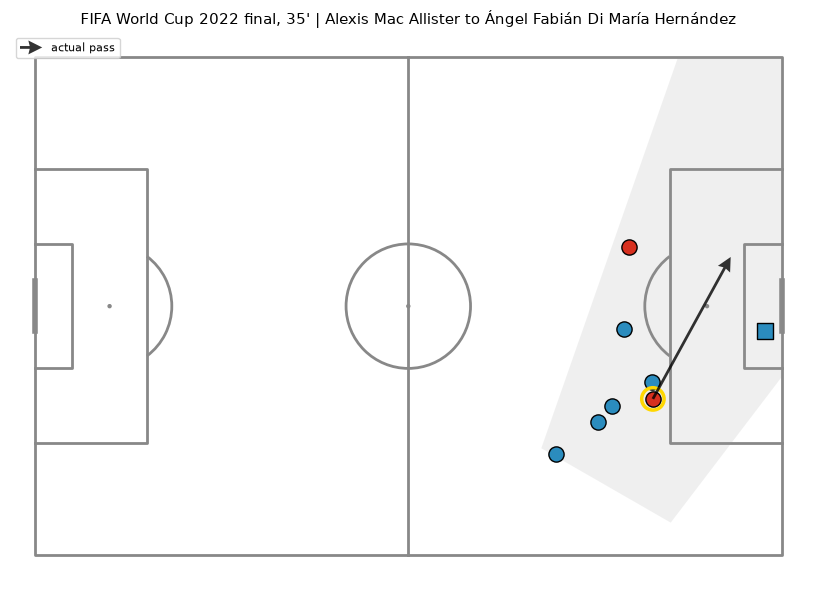

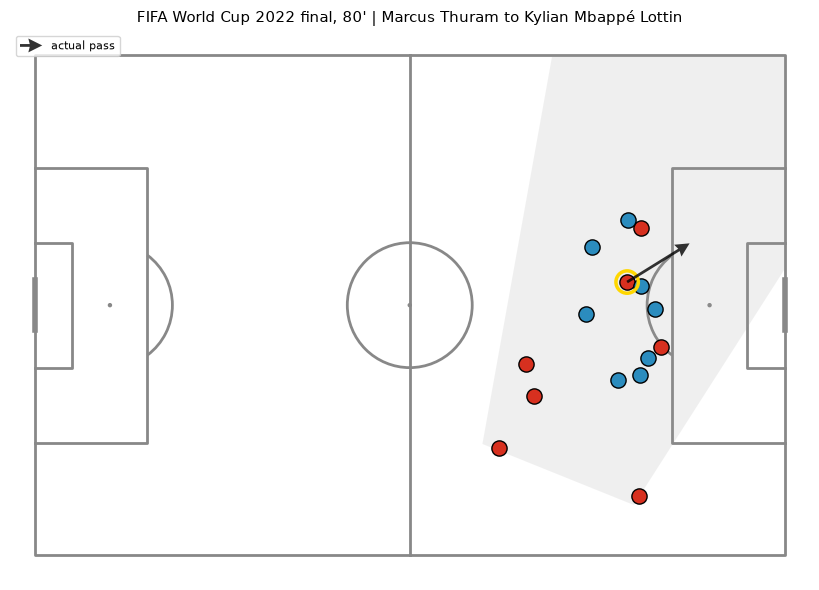

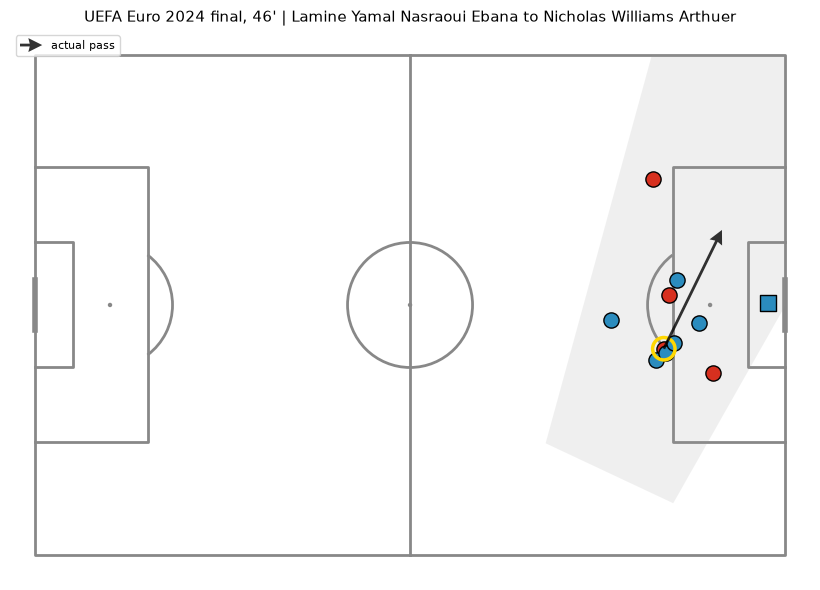

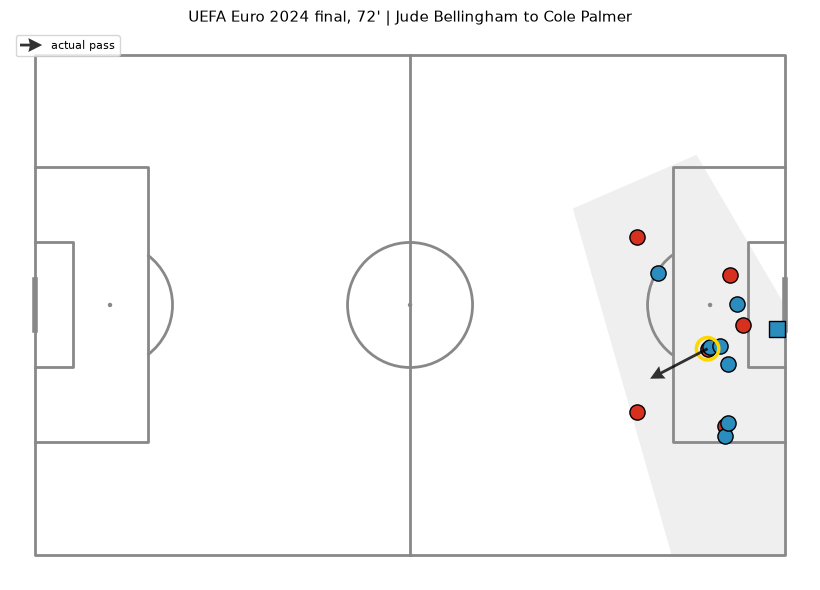

In [11]:
finals = matches[matches["competition_stage_name"] == "Final"]
ga = events[events["match_id"].isin(finals["match_id"]) & events["pass_goal_assist"]
            & events["event_id"].isin(frames["event_id"])]
display(ga[["minute", "team", "player", "pass_recipient"]].assign(comp=ga["match_id"].map(comp_of)))
for _, e in ga.head(4).iterrows():
    ax = plot_freeze_frame(frame_players(e["event_id"]), frame_area(e["event_id"]),
        passes=[dict(start=(e["x"], e["y"]), end=(e["pass_end_x"], e["pass_end_y"]), color="k",
                     label="actual pass")],
        title=f"{comp_of[e['match_id']]} final, {e['minute']}' | {e['player']} to {e['pass_recipient']}")
    ax.figure.savefig(OUT / f"famous_{e['event_id'][:8]}.png", dpi=150, bbox_inches="tight")